In [4]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [5]:
iris = load_iris()

X = iris.data       # Input features
y = iris.target     # Output labels

print("Feature names:", iris.feature_names)
print("Class names:", iris.target_names)
print("Dataset shape:", X.shape)

print("\nFirst 5 samples:")
print(X[:5])

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class names: ['setosa' 'versicolor' 'virginica']
Dataset shape: (150, 4)

First 5 samples:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,      # 20% data for testing
    random_state=42,     # Same result every time
    stratify=y           # Keeps class balance
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [7]:
model = Pipeline([
    ("scaler", StandardScaler()),              # Scale feature values
    ("knn", KNeighborsClassifier(n_neighbors=5))  # K = 5
])

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
predictions = model.predict(X_test)

print("First 10 predictions:", predictions[:10])
print("Actual values:", y_test[:10])

First 10 predictions: [0 2 1 1 0 1 0 0 2 1]
Actual values: [0 2 1 1 0 1 0 0 2 1]


In [9]:
accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average="weighted")

print("Accuracy:", round(accuracy * 100, 2), "%")
print("Weighted F1 Score:", round(f1, 3))

print("\nClassification Report:\n")
print(classification_report(y_test, predictions, target_names=iris.target_names))

Accuracy: 93.33 %
Weighted F1 Score: 0.933

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



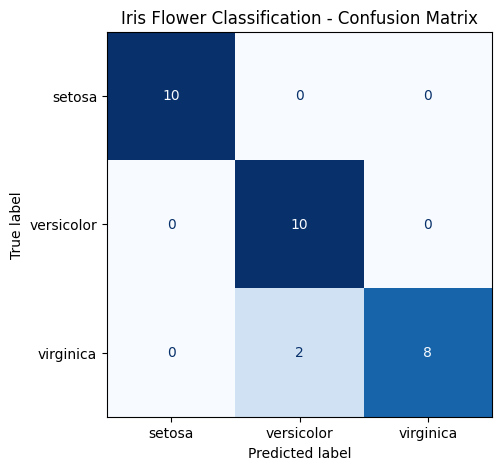

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=iris.target_names,
    cmap="Blues",
    colorbar=False,
    ax=ax
)

plt.title("Iris Flower Classification - Confusion Matrix")
plt.show()

In [11]:
# Input format:
# [sepal length, sepal width, petal length, petal width]

new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted flower species:", iris.target_names[prediction[0]])

Predicted flower species: setosa
